In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**2. Load dataset from CSV**

In [3]:
df = pd.read_csv("housing.csv")

print("Shape:", df.shape)
print("Columns:", list(df.columns))

Shape: (20640, 10)
Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


In [4]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


**housing.csv - Dataset Columns Description**

| Column Name | Description |
|------------|------------|
| longitude | Longitude of the location where the houses are located |
| latitude | Latitude of the location where the houses are located |
| housing_median_age | Median age of the houses in the area (in years) |
| total_rooms | Total number of rooms in all houses in the area |
| total_bedrooms | Total number of bedrooms in all houses in the area |
| population | Total number of people living in the area |
| households | Total number of households in the area |
| median_income | Median income of households in the area (in tens of thousands of dollars) |
| median_house_value | Median house value in the area (this is the target variable) |
| ocean_proximity | Category indicating how close the area is to the ocean |

**Notes**
- Each row represents information about a **geographical area**.
- Our goal in this regression problem is to **predict `median_house_value`**.
- `ocean_proximity` is a **categorical feature**.  
  For simplicity in this hands-on demo, we drop it and work only with numerical features.

**3. Quick checks (high-level only)**

In [5]:
print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget summary:")
print(df["median_house_value"].describe())


Missing values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Target summary:
count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64


In [6]:
# dropping rows with missing values (just for simplicity - not recommended for real projects)
df = df.dropna(subset=["total_bedrooms"])

In [7]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

**4. Split features and target**

We drop `ocean_proximity` to keep the demo simple and numeric-only.

In [8]:
X = df.drop(columns=["median_house_value", "ocean_proximity"])
y = df["median_house_value"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)


X shape: (20433, 8)
y shape: (20433,)


**5. Train-test split**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (16346, 8)
X_test shape: (4087, 8)


**6. Scaling**

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**7. Train model (Linear Regression)**

In [11]:
model = LinearRegression()

In [12]:
# training the model
model.fit(X_train_scaled, y_train)

LinearRegression()

**8. Predictions**

In [13]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

In [14]:
print(y_train[:5])
print("-"*50)
print(y_test_pred[:5])

17727    227600.0
2057     110400.0
6453     248100.0
4619     305600.0
15266    214600.0
Name: median_house_value, dtype: float64
--------------------------------------------------
[197058.03752153 157508.79088918 202099.26270387 173501.82273784
 213795.18417458]


**9. Evaluation Metrics (Train & Test)**

In [15]:
def print_regression_metrics(title, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(title)
    print(f"  MAE: {mae:.2f}")
    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R^2: {r2:.2f}")

In [16]:
print_regression_metrics("TRAIN METRICS", y_train, y_train_pred)
print_regression_metrics("TEST METRICS", y_test, y_test_pred)

TRAIN METRICS
  MAE: 50629.50
  MSE: 4817977906.77
  RMSE: 69411.66
  R^2: 0.64
TEST METRICS
  MAE: 51372.67
  MSE: 4921881237.63
  RMSE: 70156.12
  R^2: 0.64


**10. Evaluation Plot**

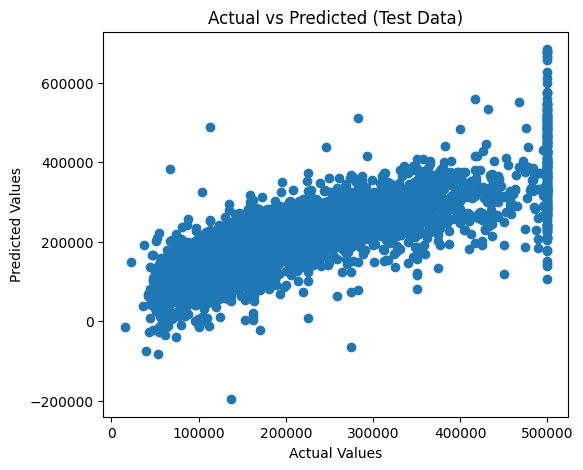

In [17]:
# actual vs predicted
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_test_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Test Data)")
plt.show()

- Loaded a real-world regression dataset from a CSV file
- Split data into training and test sets
- Applied feature scaling using StandardScaler
- Trained a Linear Regression model
- Evaluated performance using MAE, MSE, RMSE, and R²
- Visualized predictions